In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import cv2
import tensorflow as tf
from tensorflow import keras
from keras import layers, models
from keras.utils import to_categorical
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [2]:
DATASET_PATH = "dataset"  # Root directory containing Active Subjects/ and Fatigue Subjects/ folders
ALERT_FOLDER = "Active Subjects"  # Folder name for alert/active driver images
DROWSY_FOLDER = "Fatigue Subjects"  # Folder name for drowsy/fatigue driver images
IMG_SIZE = 64  # Resize images to 64x64 pixels
BATCH_SIZE = 32
EPOCHS = 25
LEARNING_RATE = 0.001
TEST_SIZE = 0.2
RANDOM_STATE = 42

In [6]:
def check_gpu_availability():
    print("\n" + "="*60)
    print("CHECKING HARDWARE CONFIGURATION")
    print("="*60)
    
    # Get list of physical devices
    gpus = tf.config.list_physical_devices('GPU')
    
    if gpus:
        try:
            # Enable memory growth to prevent TensorFlow from allocating all GPU memory
            for gpu in gpus:
                tf.config.experimental.set_memory_growth(gpu, True)
            
            print(f"✅ GPU DETECTED: {len(gpus)} GPU(s) available")
            for i, gpu in enumerate(gpus):
                print(f"   GPU {i}: {gpu.name}")
            
            # Print GPU details
            gpu_details = tf.config.experimental.get_device_details(gpus[0])
            print(f"   Device Name: {gpu_details.get('device_name', 'Unknown')}")
            
            print(f"\n🚀 Training will use GPU acceleration")
            return True
            
        except RuntimeError as e:
            print(f"⚠️ GPU detected but error during configuration: {e}")
            print("🔄 Falling back to CPU")
            return False
    else:
        print("❌ NO GPU DETECTED")
        print("💻 Training will use CPU (this may be slower)")
        
        # Check if CPU supports advanced instructions
        cpu_info = tf.config.list_physical_devices('CPU')
        if cpu_info:
            print(f"   Available CPUs: {len(cpu_info)}")
        
        return False
    
    print("="*60 + "\n")

In [7]:
def load_dataset(dataset_path, img_size):
    images = []
    labels = []
    
    # Define class names and corresponding label values
    classes = {ALERT_FOLDER: 0, DROWSY_FOLDER: 1}
    
    print("Loading dataset...")
    
    for class_name, label in classes.items():
        class_path = os.path.join(dataset_path, class_name)
        
        # Check if directory exists
        if not os.path.exists(class_path):
            print(f"Warning: Directory {class_path} does not exist!")
            continue
        
        # Load all images from the class directory
        image_files = os.listdir(class_path)
        print(f"Loading {len(image_files)} images from {class_name}/")
        
        for img_file in image_files:
            img_path = os.path.join(class_path, img_file)
            
            try:
                # Read image in grayscale (single channel)
                img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                
                if img is None:
                    continue
                
                # Resize image to fixed size
                img_resized = cv2.resize(img, (img_size, img_size))
                
                # Normalize pixel values to [0, 1]
                img_normalized = img_resized / 255.0
                
                images.append(img_normalized)
                labels.append(label)
                
            except Exception as e:
                print(f"Error loading {img_path}: {e}")
    
    # Convert lists to NumPy arrays
    images = np.array(images)
    labels = np.array(labels)
    
    # Reshape images to add channel dimension (required for CNN)
    # Shape: (num_samples, height, width, channels)
    images = images.reshape(-1, img_size, img_size, 1)
    
    print(f"\nDataset loaded successfully!")
    print(f"Total images: {len(images)}")
    print(f"Image shape: {images.shape}")
    print(f"Active/Alert images: {np.sum(labels == 0)}")
    print(f"Fatigue/Drowsy images: {np.sum(labels == 1)}")
    
    return images, labels


In [8]:
def build_cnn_model(input_shape, num_classes):
    model = models.Sequential([
        # First Convolutional Block
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape, padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        # Second Convolutional Block
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        # Third Convolutional Block
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.3),
        
        # Flatten and Dense Layers
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.4),
        
        # Output Layer
        layers.Dense(num_classes, activation='softmax')
    ])
    
    return model

In [9]:
def train_model(model, X_train, y_train, X_test, y_test, epochs, batch_size):
    # Compile model
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    # Define callbacks
    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    )
    
    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    )
    
    # Train model
    print("\nTraining model...")
    history = model.fit(
        X_train, y_train,
        batch_size=batch_size,
        epochs=epochs,
        validation_data=(X_test, y_test),
        callbacks=[early_stopping, reduce_lr],
        verbose=1
    )
    
    return history



In [10]:
def evaluate_model(model, X_test, y_test):
    # Predict on test data
    y_pred_prob = model.predict(X_test)
    y_pred = np.argmax(y_pred_prob, axis=1)
    y_true = np.argmax(y_test, axis=1)
    
    # Calculate accuracy
    test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
    print(f"\nTest Accuracy: {test_accuracy * 100:.2f}%")
    print(f"Test Loss: {test_loss:.4f}")
    
    # Classification report
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=['Alert', 'Drowsy']))
    
    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Alert', 'Drowsy'],
                yticklabels=['Alert', 'Drowsy'])
    plt.title('Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("\nConfusion matrix saved as 'confusion_matrix.png'")


In [11]:
def plot_training_history(history):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Accuracy plot
    axes[0].plot(history.history['accuracy'], label='Train Accuracy')
    axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy')
    axes[0].set_title('Model Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True)
    
    # Loss plot
    axes[1].plot(history.history['loss'], label='Train Loss')
    axes[1].plot(history.history['val_loss'], label='Validation Loss')
    axes[1].set_title('Model Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True)
    
    plt.tight_layout()
    plt.savefig('training_history.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("Training history saved as 'training_history.png'")



DRIVER DROWSINESS DETECTION - MODEL TRAINING

CHECKING HARDWARE CONFIGURATION
✅ GPU DETECTED: 1 GPU(s) available
   GPU 0: /physical_device:GPU:0
   Device Name: NVIDIA GeForce RTX 4050 Laptop GPU

🚀 Training will use GPU acceleration
Loading dataset...
Loading 4560 images from Active Subjects/
Loading 4560 images from Fatigue Subjects/

Dataset loaded successfully!
Total images: 9120
Image shape: (9120, 64, 64, 1)
Active/Alert images: 4560
Fatigue/Drowsy images: 4560

Training set size: 7296
Test set size: 1824

Model Architecture:
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 64, 64, 32)        320       
                                                                 
 batch_normalization (BatchN  (None, 64, 64, 32)       128       
 ormalization)                                                   
                                             

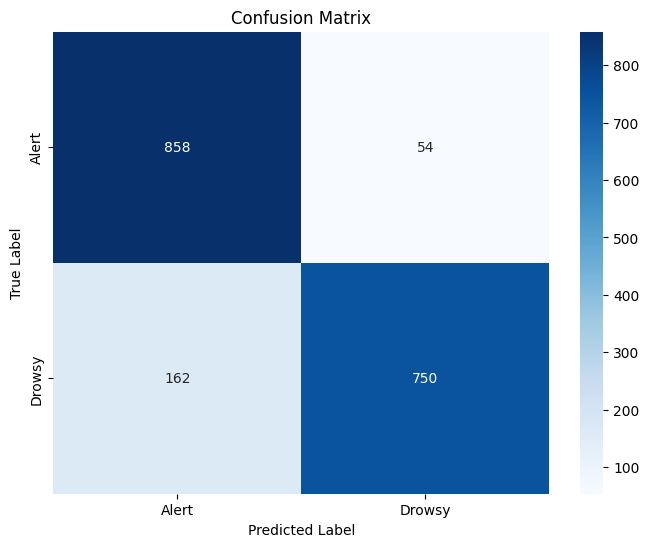


Confusion matrix saved as 'confusion_matrix.png'


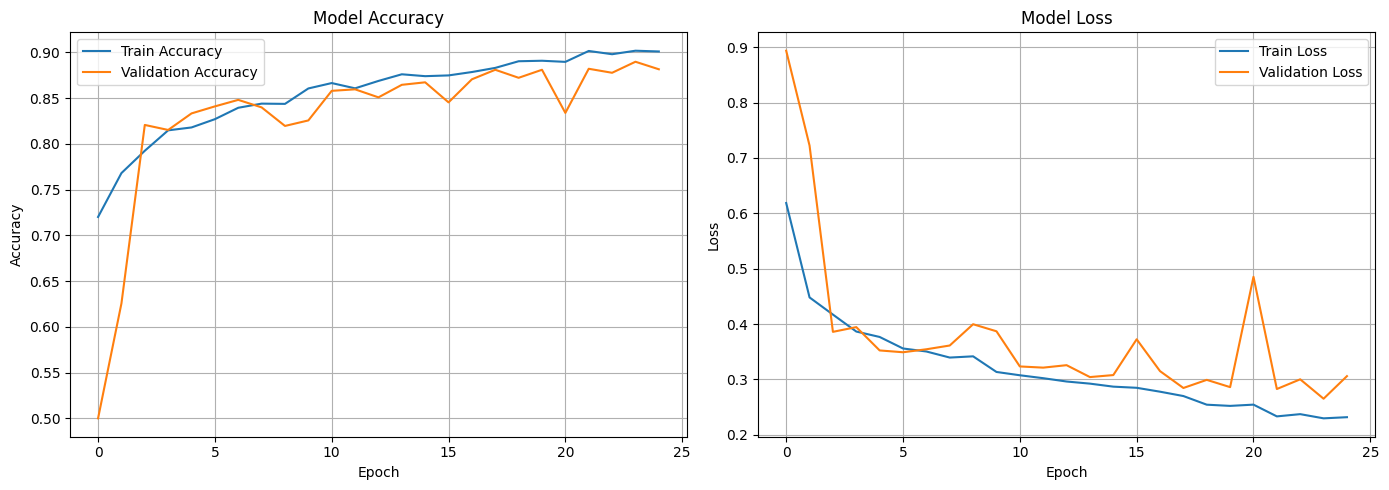

Training history saved as 'training_history.png'

✅ Model saved successfully as 'model.h5'

TRAINING COMPLETE!


In [12]:
if __name__ == "__main__":
    print("="*60)
    print("DRIVER DROWSINESS DETECTION - MODEL TRAINING")
    print("="*60)
    
    # Check GPU availability and configure
    gpu_available = check_gpu_availability()
    
    # Load and preprocess dataset
    images, labels = load_dataset(DATASET_PATH, IMG_SIZE)
    
    # Convert labels to categorical (one-hot encoding)
    labels_categorical = to_categorical(labels, num_classes=2)
    
    # Split dataset into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(
        images, labels_categorical,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        stratify=labels
    )
    
    print(f"\nTraining set size: {len(X_train)}")
    print(f"Test set size: {len(X_test)}")
    
    # Build CNN model
    input_shape = (IMG_SIZE, IMG_SIZE, 1)
    model = build_cnn_model(input_shape, num_classes=2)
    
    # Display model architecture
    print("\nModel Architecture:")
    model.summary()
    
    # Print device being used for training
    print("\n" + "="*60)
    if gpu_available:
        print("🎯 TRAINING ON: GPU")
    else:
        print("🎯 TRAINING ON: CPU")
    print("="*60 + "\n")
    
    # Train model
    history = train_model(model, X_train, y_train, X_test, y_test, EPOCHS, BATCH_SIZE)
    
    # Evaluate model
    evaluate_model(model, X_test, y_test)
    
    # Plot training history
    plot_training_history(history)
    
    # Save trained model
    model.save('model.h5')
    print("\n✅ Model saved successfully as 'model.h5'")
    
    print("\n"+"="*60)
    print("TRAINING COMPLETE!")
    print("="*60)